In [31]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.patheffects as pe
df = pd.read_csv("sales.csv", parse_dates=["Date"])

print(df.head())
print(df.shape)
print(df.dtypes)
print(type(df))

        Date CustomerName Region     Category   Product  Quantity  UnitPrice  \
0 2020-01-01  Customer_50  North  Accessories  Keyboard         2      37114   
1 2020-01-01  Customer_17   West  Accessories  Keyboard         4      25960   
2 2020-01-01  Customer_31   East  Electronics   Monitor         1      24733   
3 2020-01-02  Customer_43  North  Accessories  Keyboard         3      14345   
4 2020-01-02  Customer_39   East  Electronics   Monitor         5       1108   

   Amount  DiscountRate  TotalAmount    Profit  PaymentMode  
0   74228          0.14     63836.08  10403.64  Credit Card  
1  103840          0.06     97609.60   6958.36          UPI  
2   24733          0.12     21765.04   4653.91   Debit Card  
3   43035          0.02     42174.30   4086.91  Net Banking  
4    5540          0.14      4764.40    685.95         Cash  
(9180, 12)
Date            datetime64[us]
CustomerName               str
Region                     str
Category                   str
Product     

In [26]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")

In [27]:
print(df.isnull().sum())
print(df.describe())

Date            0
CustomerName    0
Region          0
Category        0
Product         0
Quantity        0
UnitPrice       0
Amount          0
DiscountRate    0
TotalAmount     0
Profit          0
PaymentMode     0
Month           0
Month_Name      0
dtype: int64
                             Date     Quantity     UnitPrice         Amount  \
count                        9180  9180.000000   9180.000000    9180.000000   
mean   2022-06-26 10:38:16.470588     2.991612  25321.431917   75667.394771   
min           2020-01-01 00:00:00     1.000000   1000.000000    1012.000000   
25%           2021-03-26 00:00:00     2.000000  12907.250000   28661.750000   
50%           2022-06-25 00:00:00     3.000000  25137.000000   58949.000000   
75%           2023-09-28 00:00:00     4.000000  37636.500000  111600.750000   
max           2024-12-31 00:00:00     5.000000  49973.000000  249855.000000   
std                           NaN     1.411142  14215.084353   59131.361926   

       DiscountRate    

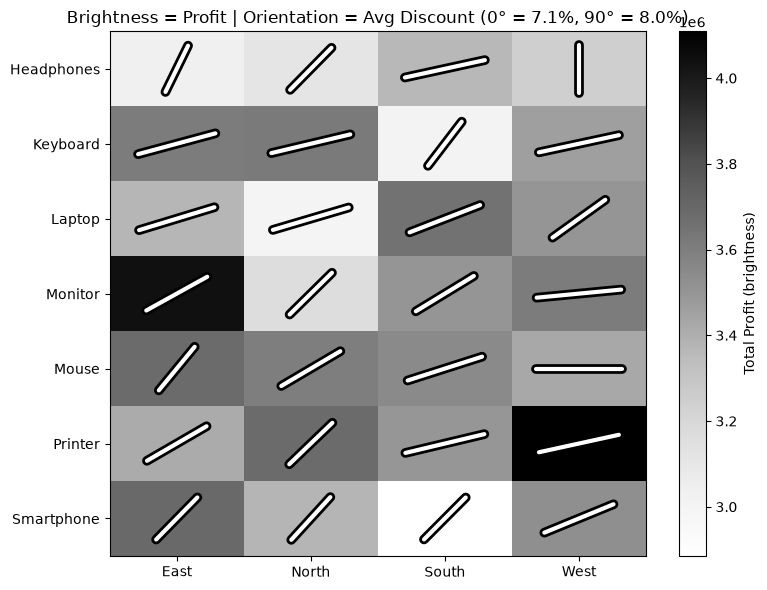

In [32]:

profit = df.pivot_table(index="Product", columns="Region", values="Profit", aggfunc="sum")
disc   = df.pivot_table(index="Product", columns="Region", values="DiscountRate", aggfunc="mean")
disc   = disc.reindex(index=profit.index, columns=profit.columns)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(profit.values, cmap="Greys", aspect="auto")
plt.colorbar(im, label="Total Profit (brightness)")

lo, hi = disc.values.min(), disc.values.max()
outline = [pe.Stroke(linewidth=7, foreground="black"), pe.Normal()]

for i in range(profit.shape[0]):
    for j in range(profit.shape[1]):
        t = np.radians(np.interp(disc.values[i, j], [lo, hi], [0, 90]))
        dx, dy = .32 * np.cos(t), .32 * np.sin(t)
        ax.plot([j - dx, j + dx], [i + dy, i - dy], color="white", lw=3,
                solid_capstyle="round", path_effects=outline)

ax.set_xticks(range(profit.shape[1]), profit.columns)
ax.set_yticks(range(profit.shape[0]), profit.index)
ax.set_title(f"Brightness = Profit | Orientation = Avg Discount "
             f"(0° = {lo:.1%}, 90° = {hi:.1%})")
plt.tight_layout(); plt.show()

In [29]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

regions = sorted(df.Region.unique())
cats = sorted(df.Category.unique())
mm = (df.assign(Month=df.Date.dt.to_period("M").astype(str))
        .pivot_table(index="Month", columns=["Region", "Category"],
                     values="TotalAmount", aggfunc="sum")
        .reindex(columns=pd.MultiIndex.from_product([regions, cats]), fill_value=0)
        .fillna(0))
months = list(mm.index)
hatch = dict(zip(cats, ["//", "..", "xx", "\\\\"]))
w = .8 / len(cats)

fig, ax = plt.subplots(figsize=(8, 5))
bars = []
for ri, r in enumerate(regions):
    for ci, c in enumerate(cats):
        b = ax.bar(ri - .4 + w * (ci + .5), mm.iloc[0][(r, c)], w, color="white",
                   edgecolor="black", hatch=hatch[c], label=c if ri == 0 else None)[0]
        bars.append((b, (r, c)))
ax.set_xticks(range(len(regions)), regions)
ax.set_ylim(0, mm.values.max() * 1.1)       # fixed axis
ax.legend(title="Category (texture)")

def update(i):
    for b, k in bars:
        b.set_height(mm.iloc[i][k])
    ax.set_title(f"Texture = Category, Motion = Month: {months[i]}")
    return [b for b, _ in bars]

anim = FuncAnimation(fig, update, frames=len(months), interval=400)
plt.close(fig)
HTML(anim.to_jshtml())

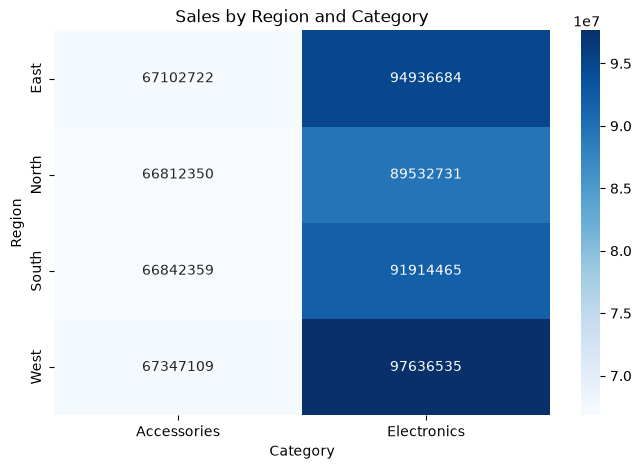

In [33]:
sales = df.pivot_table(
    values="TotalAmount",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    sales,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()

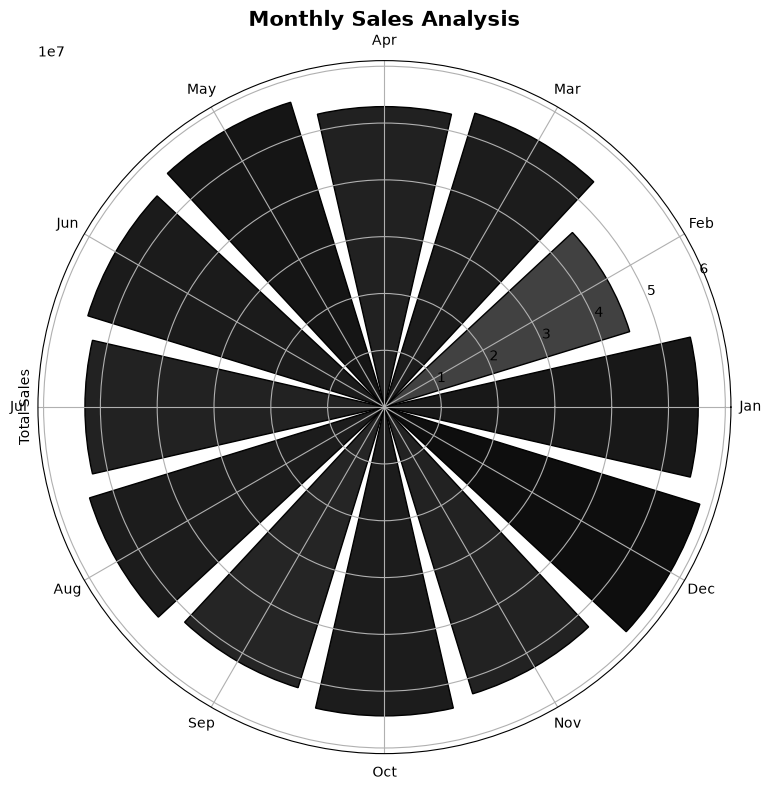

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
df = pd.read_csv("sales.csv")

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

# Monthly total sales
monthly = (
    df.groupby(df["Date"].dt.month)["TotalAmount"]
      .sum()
      .reindex(range(1, 13), fill_value=0)
)

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Angles
angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)

# Brightness: normalize sales
brightness = monthly / monthly.max()

# Plot
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})

bars = ax.bar(
    angles,
    monthly.values,
    width=0.45,
    color=plt.cm.Greys(0.25 + 0.7 * brightness),
    edgecolor="black",
    linewidth=1
)

# Month labels
ax.set_xticks(angles)
ax.set_xticklabels(months)

ax.set_title(
    "Monthly Sales Analysis",
    pad=25,
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Total Sales")

plt.show()

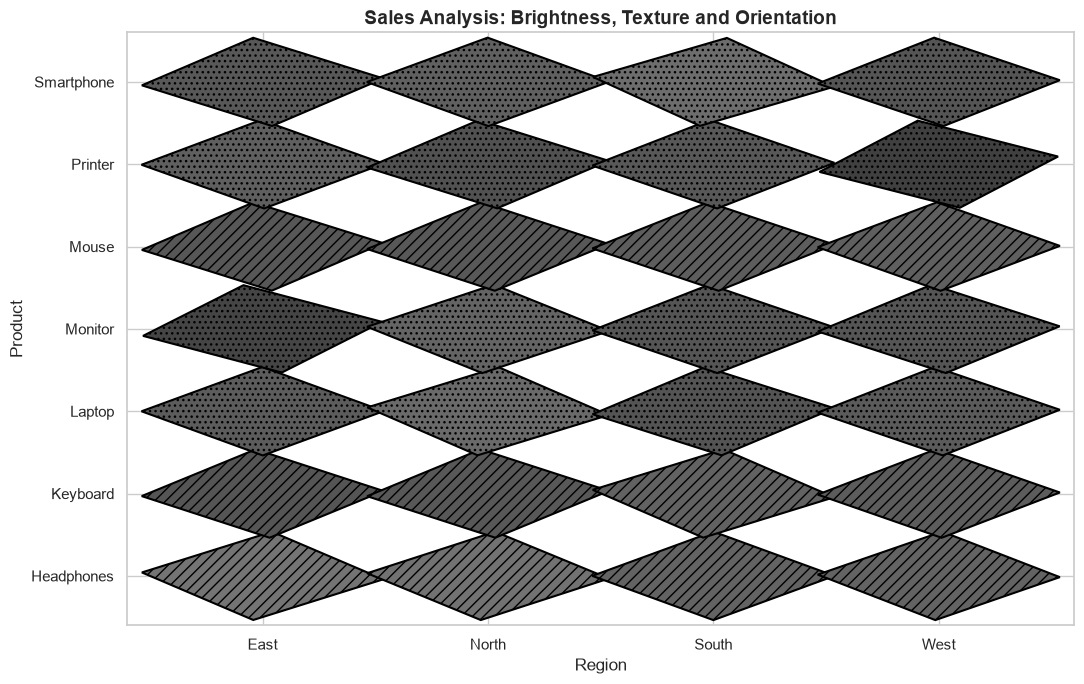

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib import transforms
import numpy as np

# Load dataset
df = pd.read_csv("sales.csv")

# Aggregate data
data = df.groupby(
    ["Region", "Product", "Category"],
    as_index=False
).agg(
    TotalAmount=("TotalAmount", "sum"),
    Profit=("Profit", "sum")
)

regions = sorted(data["Region"].unique())
products = sorted(data["Product"].unique())
categories = sorted(data["Category"].unique())

# Position mapping
x_pos = {r: i for i, r in enumerate(regions)}
y_pos = {p: i for i, p in enumerate(products)}

# Texture patterns for Category
patterns = ["///", "...", "xxx", "\\\\\\"]

# Normalize values
max_sales = data["TotalAmount"].max()
max_profit = data["Profit"].abs().max()

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 7))

for _, row in data.iterrows():

    x = x_pos[row["Region"]]
    y = y_pos[row["Product"]]

    # --------------------
    # Brightness → Sales
    # --------------------
    brightness = row["TotalAmount"] / max_sales
    shade = 1 - 0.75 * brightness

    # --------------------
    # Texture → Category
    # --------------------
    pattern = patterns[
        categories.index(row["Category"]) % len(patterns)
    ]

    # --------------------
    # Orientation → Profit
    # --------------------
    angle = np.interp(
        row["Profit"],
        [-max_profit, max_profit],
        [-55, 55]
    )

    # Create square
    square = Rectangle(
        (x - 0.38, y - 0.38),
        0.76,
        0.76,
        facecolor=str(shade),
        edgecolor="black",
        linewidth=1.5,
        hatch=pattern
    )

    # Rotate square around its center
    square.set_transform(
        transforms.Affine2D()
        .rotate_deg_around(x, y, angle)
        + ax.transData
    )

    ax.add_patch(square)

# Axis labels
ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions)

ax.set_yticks(range(len(products)))
ax.set_yticklabels(products)

ax.set_xlim(-0.6, len(regions) - 0.4)
ax.set_ylim(-0.6, len(products) - 0.4)

ax.set_xlabel("Region")
ax.set_ylabel("Product")

ax.set_title(
    "Sales Analysis: Brightness, Texture and Orientation",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

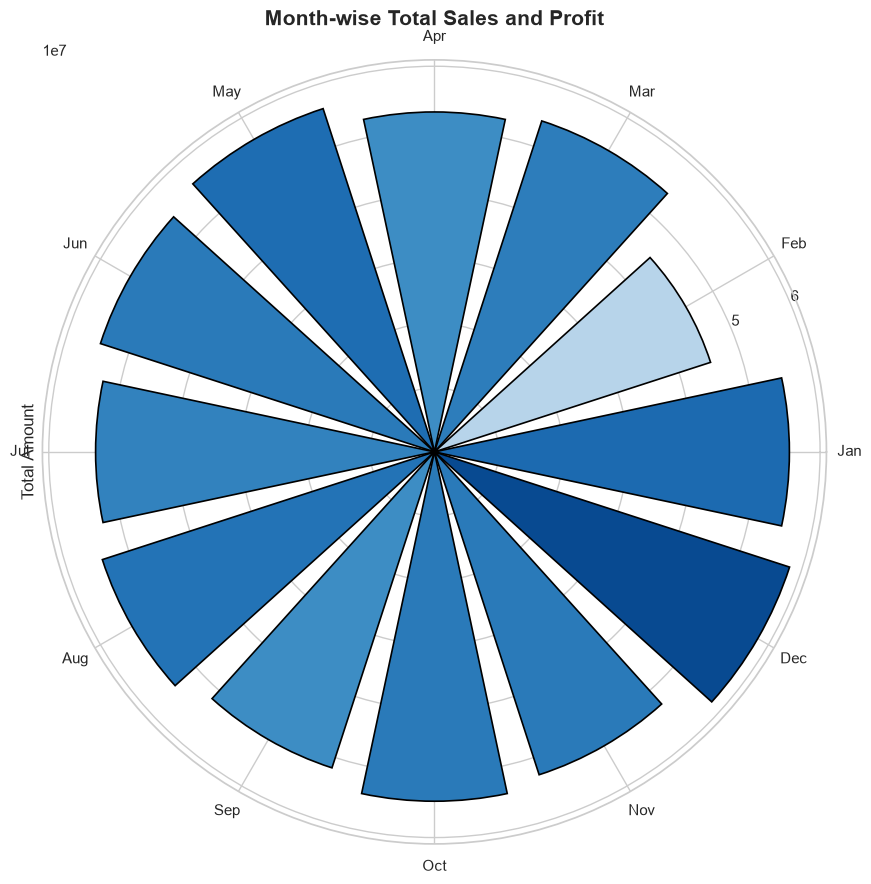

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("sales.csv")

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Month-wise sales and profit
monthly = df.groupby(
    df["Date"].dt.month
).agg(
    TotalAmount=("TotalAmount", "sum"),
    Profit=("Profit", "sum")
)

# Month names
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly = monthly.reindex(range(1, 13))

# Angles for months
angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)

# Normalize profit for color
profit_norm = (
    monthly["Profit"] - monthly["Profit"].min()
) / (
    monthly["Profit"].max() - monthly["Profit"].min()
)

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={"projection": "polar"}
)

# Radial bars
bars = ax.bar(
    angles,
    monthly["TotalAmount"],
    width=0.42,
    color=plt.cm.Blues(0.3 + 0.6 * profit_norm),
    edgecolor="black",
    linewidth=1.2
)

# Month labels
ax.set_xticks(angles)
ax.set_xticklabels(months)

ax.set_title(
    "Month-wise Total Sales and Profit",
    pad=25,
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Total Amount")

plt.tight_layout()
plt.show()

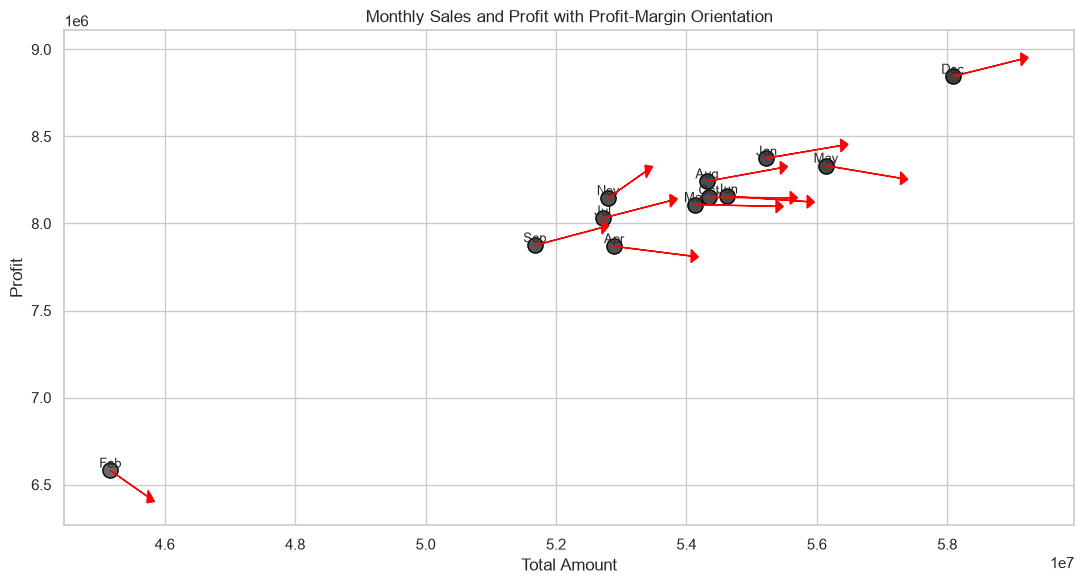

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("sales.csv")

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Month-wise aggregation
monthly = df.groupby(
    df["Date"].dt.month
).agg(
    TotalAmount=("TotalAmount", "sum"),
    Profit=("Profit", "sum")
).reset_index()

# Month names
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly["Month"] = monthly["Date"].map(
    lambda x: months[x - 1]
)

# Profit margin
monthly["ProfitMargin"] = (
    monthly["Profit"] / monthly["TotalAmount"] * 100
)

# Normalize brightness
brightness = (
    monthly["TotalAmount"] / monthly["TotalAmount"].max()
)

fig, ax = plt.subplots(figsize=(11, 6))

for i, row in monthly.iterrows():

    # Orientation based on profit margin
    angle = np.interp(
        row["ProfitMargin"],
        [monthly["ProfitMargin"].min(),
         monthly["ProfitMargin"].max()],
        [-60, 60]
    )

    # Arrow length
    length = 0.35

    dx = length * np.cos(np.radians(angle))
    dy = length * np.sin(np.radians(angle))

    # Brightness based on TotalAmount
    gray = 1 - 0.75 * brightness.iloc[i]

    ax.scatter(
        row["TotalAmount"],
        row["Profit"],
        s=120,
        color=str(gray),
        edgecolor="black",
        zorder=3
    )

    ax.arrow(
        row["TotalAmount"],
        row["Profit"],
        dx * monthly["TotalAmount"].max() / 15,
        dy * monthly["Profit"].max() / 15,
        color="red",
        width=0,
        head_width=monthly["Profit"].max() / 120,
        length_includes_head=True,
        zorder=4
    )

    ax.text(
        row["TotalAmount"],
        row["Profit"],
        row["Month"],
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xlabel("Total Amount")
ax.set_ylabel("Profit")
ax.set_title("Monthly Sales and Profit with Profit-Margin Orientation")

plt.tight_layout()
plt.show()